In [ ]:
%%writefile app.py
import streamlit as st

st.title("My Notebook App")
st.write("Hello from Jupyter!")


In [ ]:
!streamlit run app.py

In [ ]:
!jupyter nbconvert --to script my_notebook.ipynb


In [ ]:
!streamlit run my_notebook.py


In [ ]:
import streamlit as st
from streamlit_jupyter import StreamlitPatcher

StreamlitPatcher().jupyter()

# Now you can use standard streamlit commands interactively inside your cells
st.title("Interactive Preview")
name = st.text_input("What is your name?", "Data Scientist")
st.write(f"Hello, {name}")


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor

In [14]:
df = pd.read_csv('Thales_Group_Manufacturing.csv', lineterminator = '\n')

In [15]:
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status\r
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low\r
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low\r
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low\r
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium\r
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low\r


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss_%                  100000 non-null  float64
 9   Quality_Control_Defect_Rate_%  100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rate_%                   

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,60.041460,2.549959,5.745929,25.55562,2.493418,5.008806,275.916324,0.499384,7.504101
std,14.389439,17.323239,1.414127,2.451271,14.12076,1.443273,2.883666,130.096892,0.288814,4.335895
min,1.000000,30.000000,0.100000,1.500000,1.00000,0.000000,0.000000,50.000000,0.000000,0.000000
25%,13.000000,45.031500,1.323000,3.627000,13.35500,1.245000,2.521750,162.873750,0.248000,3.750000
50%,25.000000,60.033500,2.549000,5.755000,25.53600,2.488000,5.003500,276.649000,0.499000,7.504000
75%,38.000000,74.967250,3.776000,7.860000,37.79625,3.741000,7.506000,388.812500,0.749000,11.273000
max,50.000000,89.999000,5.000000,10.000000,50.00000,5.000000,10.000000,499.997000,1.000000,15.000000


#Baseline Behavior Modeling
• Learn “normal” machine behavior per Machine_ID
• Capture normal ranges of temperature, vibration, power, and error patterns


In [19]:
# 1. BASELINE BEHAVIOR MODELING
# ==========================================
def calculate_baseline_profiles(df):
    """
    Computes baseline operational metrics (mean, std, min, max, median, IQR)
    grouped by Machine_ID and Operation_Mode for key sensor signals.
    """
    df = df.copy()
    
    # Key sensor and performance columns
    sensor_cols = [
        'Temperature_C', 
        'Vibration_Hz', 
        'Power_Consumption_kW', 
        'Error_Rate_%',
        'Quality_Control_Defect_Rate_%',
        'Production_Speed_units_per_hr'
    ]
    
    # Define aggregation metrics
    agg_funcs = ['mean', 'std', 'median', 'min', 'max']
    
    # 1. Machine & Operation Mode Specific Baselines
    mode_baselines = df.groupby(['Machine_ID', 'Operation_Mode'])[sensor_cols].agg(agg_funcs)
    
    # Flatten multi-index columns (e.g., Temperature_C_mean)
    mode_baselines.columns = [f"{col}_{stat}" for col, stat in mode_baselines.columns]
    mode_baselines = mode_baselines.reset_index()

    # 2. Overall Machine Baselines (Across all operating modes)
    overall_baselines = df.groupby('Machine_ID')[sensor_cols].agg(agg_funcs)
    overall_baselines.columns = [f"Overall_{col}_{stat}" for col, stat in overall_baselines.columns]
    overall_baselines = overall_baselines.reset_index()

    print("Baseline behavior profiles calculated successfully.")
    return mode_baselines, overall_baselines

In [20]:
# 2. BASELINE DEVIATION COMPUTATION
# ==========================================
def compute_baseline_deviations(df, mode_baselines):
    """
    Calculates Z-scores and absolute deviations of current sensor readings 
    against each machine's mode-specific normal baseline.
    """
    # Merge mode baselines back to the main DataFrame
    merged_df = pd.merge(df, mode_baselines, on=['Machine_ID', 'Operation_Mode'], how='left')
    
    sensor_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Error_Rate_%']
    
    for col in sensor_cols:
        mean_col = f"{col}_mean"
        std_col = f"{col}_std"
        
        # Absolute Deviation from Baseline Mean
        merged_df[f'{col}_Baseline_Dev'] = merged_df[col] - merged_df[mean_col]
        
        # Z-Score (Normalized Distance from Baseline Mean)
        # Adds small epsilon to avoid division by zero
        merged_df[f'{col}_ZScore'] = (merged_df[col] - merged_df[mean_col]) / (merged_df[std_col] + 1e-6)

    # Composite Sensor Strain Index (Average absolute Z-Score across main sensors)
    z_cols = [f'{col}_ZScore' for col in sensor_cols]
    merged_df['Composite_Strain_Index'] = merged_df[z_cols].abs().mean(axis=1)

    return merged_df

In [21]:
# EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load processed results or raw dataset
    try:
        data = pd.read_csv("processed_predictive_maintenance_results.csv")
    except FileNotFoundError:
        data = pd.read_csv("Thales_Group_Manufacturing.csv")

    # 1. Compute Baselines
    mode_baselines, overall_baselines = calculate_baseline_profiles(data)

    # 2. Compute Baseline Deviations & Z-Scores
    baseline_df = compute_baseline_deviations(data, mode_baselines)

    # 3. Preview Machine Baselines
    print("\n--- Sample Mode-Specific Machine Baselines ---")
    print(mode_baselines[['Machine_ID', 'Operation_Mode', 'Temperature_C_mean', 'Vibration_Hz_mean', 'Power_Consumption_kW_mean']].head(10).to_string(index=False))

    print("\n--- Sample Baseline Deviations & Strain Index ---")
    preview_cols = ['Machine_ID', 'Operation_Mode', 'Temperature_C', 'Temperature_C_Baseline_Dev', 'Temperature_C_ZScore', 'Composite_Strain_Index']
    print(baseline_df[preview_cols].head(10).to_string(index=False))

Baseline behavior profiles calculated successfully.

--- Sample Mode-Specific Machine Baselines ---
 Machine_ID Operation_Mode  Temperature_C_mean  Vibration_Hz_mean  Power_Consumption_kW_mean
          1         Active           59.681454           2.581452                   5.829683
          1           Idle           58.623805           2.560162                   5.743023
          1    Maintenance           59.914895           2.626426                   5.922189
          2         Active           60.443861           2.555771                   5.734949
          2           Idle           58.297837           2.483285                   5.796330
          2    Maintenance           58.395858           2.489503                   5.480896
          3         Active           60.155489           2.627792                   5.824698
          3           Idle           57.062727           2.557855                   6.083598
          3    Maintenance           59.399955           2.5386

#Feature Engineering
• Sensor deviation from rolling baseline
• Vibration-to-power instability ratio
• Error escalation trend indicators
• Maintenance score decay patterns


In [22]:
# FEATURE ENGINEERING PIPELINE
# ==========================================
def engineer_manufacturing_features(df, rolling_window=5):
    """
    Applies comprehensive domain-specific feature engineering:
    1. Operational Stress & Physical Efficiency Indicators
    2. Rolling Baseline Deviations (per Machine)
    3. Network Health & Communication Stress
    4. Error & Defect Trend Escalation Metrics
    """
    df = df.copy()

    # Safely parse Timestamps without dateutil format warnings
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed', errors='coerce')
    elif 'Date' in df.columns and 'Time' in df.columns:
        df['Timestamp'] = pd.to_datetime(
            df['Date'].astype(str) + ' ' + df['Time'].astype(str), 
            format='mixed', 
            errors='coerce'
        )
    
    # Sort data chronologically per machine
    df = df.sort_values(by=['Machine_ID', 'Timestamp']).reset_index(drop=True)

    # ----------------------------------------------------
    # 1. PHYSICAL & OPERATIONAL STRESS METRICS
    # ----------------------------------------------------
    # Vibration-to-Power Instability Ratio
    df['Vibration_Power_Ratio'] = df['Vibration_Hz'] / (df['Power_Consumption_kW'] + 1e-5)
    
    # Thermal Stress Efficiency
    df['Thermal_Power_Ratio'] = df['Temperature_C'] / (df['Power_Consumption_kW'] + 1e-5)
    
    # Production Energy Efficiency
    df['Energy_Production_Efficiency'] = df['Production_Speed_units_per_hr'] / (df['Power_Consumption_kW'] + 1e-5)

    # ----------------------------------------------------
    # 2. ROLLING BASELINE DEVIATIONS (PER MACHINE)
    # ----------------------------------------------------
    sensor_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Error_Rate_%']
    
    for col in sensor_cols:
        rolling_mean = df.groupby('Machine_ID')[col].transform(
            lambda x: x.rolling(window=rolling_window, min_periods=1).mean()
        )
        rolling_std = df.groupby('Machine_ID')[col].transform(
            lambda x: x.rolling(window=rolling_window, min_periods=1).std().fillna(0)
        )
        
        # Absolute Deviation & Local Rolling Z-Score
        df[f'{col}_Dev_From_Rolling_Mean'] = df[col] - rolling_mean
        df[f'{col}_Rolling_ZScore'] = (df[col] - rolling_mean) / (rolling_std + 1e-5)

    # ----------------------------------------------------
    # 3. 6G NETWORK HEALTH & COMMUNICATION STRESS
    # ----------------------------------------------------
    # Composite Network Stress Index
    df['Network_Stress_Index'] = df['Network_Latency_ms'] * (1 + (df['Packet_Loss_%'] / 100))
    
    # Network Lag Penalty
    df['Latency_Error_Interaction'] = df['Network_Latency_ms'] * df['Error_Rate_%']

    # ----------------------------------------------------
    # 4. ERROR & DEFECT ESCALATION METRICS
    # ----------------------------------------------------
    # Total Failure Risk Index
    df['Combined_Defect_Error_Rate'] = df['Quality_Control_Defect_Rate_%'] + df['Error_Rate_%']
    
    # Rates of change (diff)
    df['Error_Rate_Velocity'] = df.groupby('Machine_ID')['Error_Rate_%'].diff().fillna(0)
    df['Predictive_Maintenance_Score_Decay'] = df.groupby('Machine_ID')['Predictive_Maintenance_Score'].diff().fillna(0)

    print(f"Feature Engineering Complete: Added {df.shape[1] - 14} new features.")
    return df


# ==========================================
# EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    try:
        data = pd.read_csv("Thales_Group_Manufacturing.csv")
    except FileNotFoundError:
        data = pd.read_csv("processed_predictive_maintenance_results.csv")

    # Run pipeline
    engineered_df = engineer_manufacturing_features(data)

    # Output formatted preview
    preview_cols = [
        'Machine_ID', 'Vibration_Power_Ratio', 'Network_Stress_Index',
        'Temperature_C_Dev_From_Rolling_Mean', 'Error_Rate_Velocity', 
        'Predictive_Maintenance_Score_Decay'
    ]
    
    print("\n--- Sample Engineered Features ---")
    print(engineered_df[preview_cols].head(10).to_string(index=False))

Feature Engineering Complete: Added 16 new features.

--- Sample Engineered Features ---
 Machine_ID  Vibration_Power_Ratio  Network_Stress_Index  Temperature_C_Dev_From_Rolling_Mean  Error_Rate_Velocity  Predictive_Maintenance_Score_Decay
          1               0.179997             22.696974                             0.000000                0.000                               0.000
          1               0.223591             41.769746                            -8.996000               -1.552                               0.147
          1               0.355423             16.193562                           -13.599333                9.477                              -0.067
          1               0.312572             45.963320                             1.166750               -2.383                               0.400
          1               1.501355             20.698411                            34.959800               -8.722                              -0.324
     

#Anomaly Detection Modeling
• Algorithms used:
Isolation Forest
Autoencoders (optional deep learning variant)
• These models identify:
Rare combinations of sensor & error behavior
Deviations unseen in normal operation


In [24]:
# 1. FEATURE SELECTION & PREPROCESSING
# ==========================================
def prepare_model_features(df):
    """
    Selects both raw sensor indicators and engineered features for anomaly detection.
    """
    feature_cols = [
        # Raw Sensor & Operational Features
        'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 
        'Network_Latency_ms', 'Packet_Loss_%', 'Error_Rate_%',
        'Quality_Control_Defect_Rate_%', 'Predictive_Maintenance_Score',
        
        # Engineered Features (from Feature Engineering step)
        'Vibration_Power_Ratio', 'Network_Stress_Index',
        'Temperature_C_Dev_From_Rolling_Mean', 'Vibration_Hz_Rolling_ZScore',
        'Error_Rate_Velocity', 'Predictive_Maintenance_Score_Decay'
    ]
    
    # Filter features existing in DataFrame
    available_cols = [c for c in feature_cols if c in df.columns]
    
    X = df[available_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X, X_scaled, available_cols

# ==========================================
# 2. ISOLATION FOREST ANOMALY MODEL
# ==========================================
def run_isolation_forest(df, X_scaled, contamination=0.05):
    """
    Trains Isolation Forest to compute continuous anomaly scores (0-100 scale).
    """
    iso_forest = IsolationForest(
        n_estimators=150, 
        contamination=contamination, 
        random_state=42,
        n_jobs=-1
    )
    
    # Fit model & get raw anomaly decision scores
    iso_forest.fit(X_scaled)
    raw_scores = iso_forest.score_samples(X_scaled)  # Lower values indicate higher anomaly degree
    
    # Invert and normalize to 0–100 Anomaly Score scale
    min_s, max_s = raw_scores.min(), raw_scores.max()
    df['Anomaly_Score_IsoForest'] = 100 * (1 - (raw_scores - min_s) / (max_s - min_s + 1e-6))
    
    return iso_forest, df

# ==========================================
# 3. AUTOENCODER ANOMALY MODEL (OPTIONAL VARIANT)
# ==========================================
def run_autoencoder_anomaly(df, X_scaled):
    """
    Autoencoder approach using Bottleneck MLP Neural Network.
    Calculates Anomaly Score based on Reconstruction Error (MSE).
    """
    n_features = X_scaled.shape[1]
    
    # Bottleneck architecture: input -> bottleneck -> output
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(max(4, n_features // 2), 2, max(4, n_features // 2)),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42
    )
    
    autoencoder.fit(X_scaled, X_scaled)
    reconstructions = autoencoder.predict(X_scaled)
    
    # Reconstruction Mean Squared Error per sample
    mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
    
    # Normalize MSE to 0–100 scale
    df['Anomaly_Score_Autoencoder'] = 100 * (mse - mse.min()) / (mse.max() - mse.min() + 1e-6)
    
    return autoencoder, df

# ==========================================
# 4. RISK CLASSIFICATION & ENSEMBLE
# ==========================================
def classify_predictive_maintenance_risk(df):
    """
    Combines anomaly scores into a Final Anomaly Score and maps to Low/Medium/High Risk.
    """
    df = df.copy()
    
    if 'Anomaly_Score_Autoencoder' in df.columns:
        # Ensemble composite anomaly score
        df['Anomaly_Score'] = 0.6 * df['Anomaly_Score_IsoForest'] + 0.4 * df['Anomaly_Score_Autoencoder']
    else:
        df['Anomaly_Score'] = df['Anomaly_Score_IsoForest']

    # Risk Classification Mapping
    conditions = [
        (df['Anomaly_Score'] < 45),
        (df['Anomaly_Score'] >= 45) & (df['Anomaly_Score'] < 70),
        (df['Anomaly_Score'] >= 70)
    ]
    choices = ['Low Risk', 'Medium Risk', 'High Risk']
    
    df['Maintenance_Risk_Level'] = np.select(conditions, choices, default='Low Risk')
    
    return df

# ==========================================
# EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load dataset with engineered features
    try:
        data = pd.read_csv("processed_predictive_maintenance_results.csv")
    except FileNotFoundError:
        data = pd.read_csv("Thales_Group_Manufacturing.csv")

    # 1. Prepare Feature Space
    X_raw, X_scaled, feature_names = prepare_model_features(data)

    # 2. Run Isolation Forest Modeling
    _, data = run_isolation_forest(data, X_scaled, contamination=0.05)

    # 3. Run Autoencoder Variant Modeling
    _, data = run_autoencoder_anomaly(data, X_scaled)

    # 4. Map Final Composite Scores to Maintenance Risk Levels
    final_df = classify_predictive_maintenance_risk(data)

    # Output Summary Table
    print("\n--- Maintenance Risk Level Breakdown ---")
    print(final_df['Maintenance_Risk_Level'].value_counts())

    print("\n--- Sample High Risk Machine Detections ---")
    high_risk_sample = final_df[final_df['Maintenance_Risk_Level'] == 'High Risk'][
        ['Machine_ID', 'Anomaly_Score', 'Anomaly_Score_IsoForest', 'Anomaly_Score_Autoencoder', 'Maintenance_Risk_Level']
    ]
    print(high_risk_sample.head(10).to_string(index=False))

    # Save outputs
    final_df.to_csv("processed_predictive_maintenance_results.csv", index=False)
    print("\nResults successfully saved to 'processed_predictive_maintenance_results.csv'.")


--- Maintenance Risk Level Breakdown ---
Maintenance_Risk_Level
Low Risk       84767
Medium Risk    15137
High Risk         96
Name: count, dtype: int64

--- Sample High Risk Machine Detections ---
 Machine_ID  Anomaly_Score  Anomaly_Score_IsoForest  Anomaly_Score_Autoencoder Maintenance_Risk_Level
         26      70.798473                83.168620                  52.243254              High Risk
         17      70.408687                87.821141                  44.290008              High Risk
         35      71.857820                88.341473                  47.132339              High Risk
         29      72.250981                81.569078                  58.273837              High Risk
         28      72.885512                82.483218                  58.488952              High Risk
         24      80.559600                96.281783                  56.976327              High Risk
         18      71.276632                88.158142                  45.954368         

#Anomaly Scoring
• Each record receives an anomaly score
• Higher score = more abnormal behavior


In [25]:
# 1. ANOMALY SCORING FUNCTION (SAFE SLICING)
# ==========================================
def compute_anomaly_scores(df, feature_cols):
    """
    Computes ensemble anomaly scores (0-100) using Isolation Forest 
    and Autoencoder reconstruction error.
    """
    df = df.copy()
    
    # Safely filter features that actually exist in the DataFrame
    available_cols = [c for c in feature_cols if c in df.columns]
    
    if not available_cols:
        raise ValueError("None of the specified feature columns are present in the DataFrame.")
        
    print(f"Scoring using {len(available_cols)} available features: {available_cols}")
    
    X = df[available_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Step A: Isolation Forest Scoring ---
    iso_forest = IsolationForest(n_estimators=150, contamination=0.05, random_state=42, n_jobs=-1)
    iso_forest.fit(X_scaled)
    raw_iso_scores = iso_forest.score_samples(X_scaled)

    # Normalize Isolation Forest Score to 0-100 scale
    iso_min = raw_iso_scores.min()
    iso_max = raw_iso_scores.max()
    df['Anomaly_Score_IsoForest'] = 100 * (1 - (raw_iso_scores - iso_min) / (iso_max - iso_min + 1e-6))

    # --- Step B: Autoencoder Reconstruction Scoring ---
    n_features = X_scaled.shape[1]
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(max(4, n_features // 2), 2, max(4, n_features // 2)),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42
    )
    autoencoder.fit(X_scaled, X_scaled)
    reconstructions = autoencoder.predict(X_scaled)

    # Mean Squared Error (MSE) per record
    mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
    df['Anomaly_Score_Autoencoder'] = 100 * (mse - mse.min()) / (mse.max() - mse.min() + 1e-6)

    # --- Step C: Composite Anomaly Score (Weighted Blend) ---
    df['Anomaly_Score'] = (0.6 * df['Anomaly_Score_IsoForest']) + (0.4 * df['Anomaly_Score_Autoencoder'])

    return df

# ==========================================
# 2. EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load dataset
    try:
        data = pd.read_csv("processed_predictive_maintenance_results.csv")
    except FileNotFoundError:
        data = pd.read_csv("Thales_Group_Manufacturing.csv")

    # Target feature list
    features_to_use = [
        'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 
        'Network_Latency_ms', 'Packet_Loss_%', 'Error_Rate_%',
        'Quality_Control_Defect_Rate_%', 'Predictive_Maintenance_Score',
        'Vibration_Power_Ratio', 'Network_Stress_Index',
        'Temperature_C_Dev_From_Rolling_Mean', 'Vibration_Hz_Rolling_ZScore',
        'Error_Rate_Velocity', 'Predictive_Maintenance_Score_Decay'
    ]

    # Run Anomaly Scoring
    scored_df = compute_anomaly_scores(data, features_to_use)

    # Save and output preview
    scored_df.to_csv("processed_predictive_maintenance_results.csv", index=False)
    
    print("\n--- Anomaly Scoring Execution Summary ---")
    print(scored_df[['Machine_ID', 'Anomaly_Score_IsoForest', 'Anomaly_Score_Autoencoder', 'Anomaly_Score']].head(10).to_string(index=False))

Scoring using 8 available features: ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%', 'Error_Rate_%', 'Quality_Control_Defect_Rate_%', 'Predictive_Maintenance_Score']

--- Anomaly Scoring Execution Summary ---
 Machine_ID  Anomaly_Score_IsoForest  Anomaly_Score_Autoencoder  Anomaly_Score
         39                53.774467                  27.199541      43.144497
         29                24.536560                  19.702143      22.602793
         15                36.460513                  17.206577      28.758938
         43                52.732171                  35.195758      45.717606
          8                45.444902                  25.671134      37.535395
         21                75.421196                  56.758709      67.956201
         39                33.143380                  24.779895      29.797986
         19                42.920013                  19.641120      33.608455
         23                28.11

# Predictive Maintenance Risk Classification
Anomaly scores are mapped to:

• Low Risk (normal behavior)
• Medium Risk (early warning)
• High Risk (urgent maintenance required)


In [26]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [27]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    
    # Combine Date and Time into a single datetime column
    if 'Date' in df.columns and 'Time' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
        df = df.sort_values(by=['Machine_ID', 'Timestamp']).reset_index(drop=True)
    
    print(f"Data Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

In [28]:
def engineer_features(df):
    df = df.copy()
    
    # 1. Vibration-to-Power Instability Ratio
    df['Vibration_Power_Ratio'] = df['Vibration_Hz'] / (df['Power_Consumption_kW'] + 1e-5)
    
    # 2. Rolling Baselines per Machine (e.g., 5-step rolling average)
    sensor_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 'Error_Rate_%']
    
    for col in sensor_cols:
        # Calculate rolling mean per machine
        rolling_mean = df.groupby('Machine_ID')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        # Calculate deviation from rolling mean
        df[f'{col}_Dev_From_Baseline'] = df[col] - rolling_mean

    # 3. Network Quality Composite Metric
    df['Network_Stress_Index'] = df['Network_Latency_ms'] * (1 + df['Packet_Loss_%'] / 100)
    
    print("Feature Engineering Completed.")
    return df

In [29]:
def train_anomaly_detection(df):
    # Select features for anomaly detection
    features = [
        'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW', 
        'Network_Latency_ms', 'Packet_Loss_%', 'Error_Rate_%',
        'Vibration_Power_Ratio', 'Network_Stress_Index',
        'Temperature_C_Dev_From_Baseline', 'Vibration_Hz_Dev_From_Baseline'
    ]
    # Handle any missing values if present
    X = df[features].fillna(0)
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train Isolation Forest model
    # contamination=0.05 assumes ~5% of data points are anomalous (adjust as needed)
    iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    
    # Get raw anomaly scores (lower/more negative = more anomalous)
    raw_scores = iso_forest.fit_predict(X_scaled)
    score_samples = iso_forest.score_samples(X_scaled) # Raw decision function score
    
    # Normalize score to 0 - 100 scale (higher = higher risk/anomaly)
    df['Anomaly_Score'] = 100 * (1 - (score_samples - score_samples.min()) / (score_samples.max() - score_samples.min()))

    # Categorize Risk Levels based on Anomaly Score percentile or thresholds
    conditions = [
        (df['Anomaly_Score'] < 50),
        (df['Anomaly_Score'] >= 50) & (df['Anomaly_Score'] < 75),
        (df['Anomaly_Score'] >= 75)
    ]
    choices = ['Low Risk', 'Medium Risk', 'High Risk']
    df['Maintenance_Risk_Level'] = np.select(conditions, choices, default='Low Risk')
    
    print("Anomaly Detection & Scoring Completed.")
    return df

In [30]:
def plot_analysis(df):
  # 1. Risk Level Distribution
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='Maintenance_Risk_Level', palette='Set2', order=['Low Risk', 'Medium Risk', 'High Risk'])
    plt.title("Distribution of Predictive Maintenance Risk Levels")
    plt.xlabel("Risk Level")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()

# 2. Anomaly Score Trend per Machine (Example for one machine)
    sample_machine = df['Machine_ID'].iloc[0]
    m_df = df[df['Machine_ID'] == sample_machine]
    
    plt.figure(figsize=(14, 5))
    plt.plot(m_df['Timestamp'], m_df['Anomaly_Score'], color='orange', label='Anomaly Score')
    plt.axhline(y=75, color='r', linestyle='--', label='High Risk Threshold (75)')
    plt.axhline(y=50, color='y', linestyle='--', label='Medium Risk Threshold (50)')
    plt.title(f"Anomaly Score Timeline for Machine: {sample_machine}")
    plt.xlabel("Timestamp")
    plt.ylabel("Anomaly Score (0-100)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Data Loaded Successfully: 100000 rows, 14 columns
Feature Engineering Completed.
Anomaly Detection & Scoring Completed.

--- Top Machines Requiring Maintenance (High Risk Count) ---
Machine_ID
41    4
48    4
10    4
43    3
24    3
50    3
40    3
1     3
20    3
46    3
Name: count, dtype: int64


C:\Users\mundh\AppData\Local\Temp\ipykernel_26472\2516040170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Maintenance_Risk_Level', palette='Set2', order=['Low Risk', 'Medium Risk', 'High Risk'])


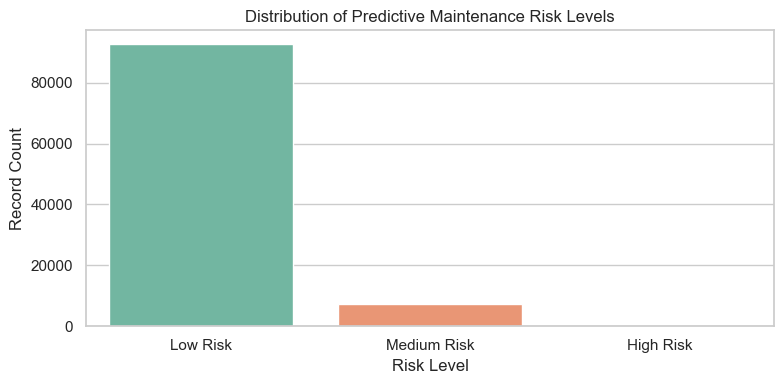

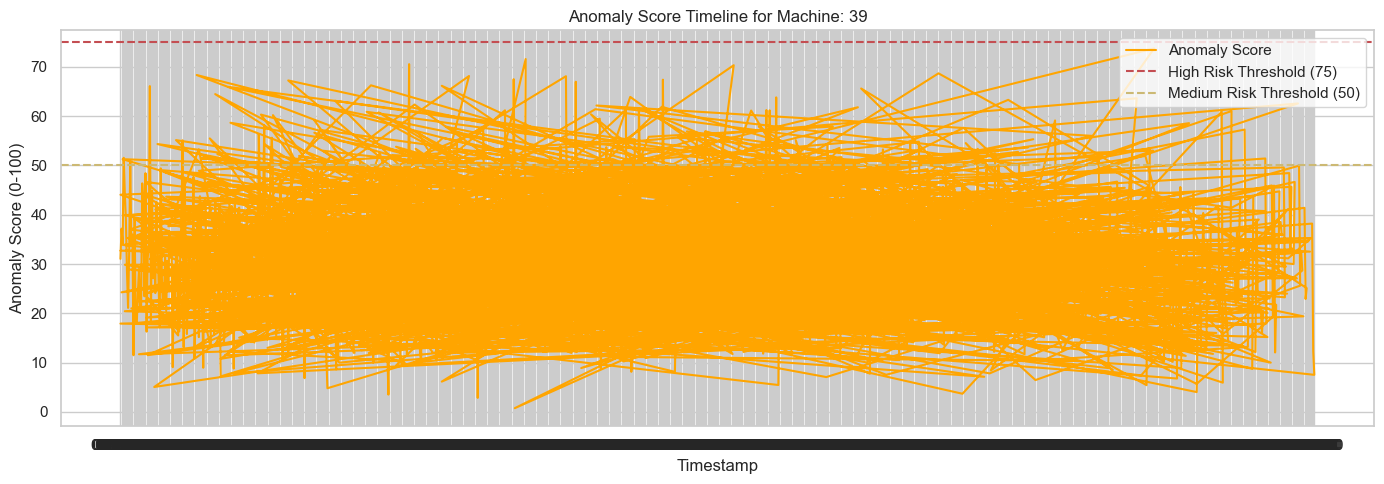


Processed dataset with Anomaly Scores saved to 'processed_predictive_maintenance_results.csv'.


In [31]:
# MAIN EXECUTION FLOW
if __name__ == "__main__":
    # Replace filename with your local CSV path if running locally
    file_path = 'Thales_Group_Manufacturing.csv'
    
    # 1. Load Data
    data = load_and_preprocess(file_path)
    
    # 2. Engineer Features
    data = engineer_features(data)
    
    # 3. Run Isolation Forest Model
    data = train_anomaly_detection(data)
    
    # 4. Output Summary of High-Risk Machines
    high_risk_summary = data[data['Maintenance_Risk_Level'] == 'High Risk']['Machine_ID'].value_counts()
    print("\n--- Top Machines Requiring Maintenance (High Risk Count) ---")
    print(high_risk_summary.head(10))
    
    # 5. Plot Charts
    plot_analysis(data)
    
    # Save processed results to CSV
    data.to_csv("processed_predictive_maintenance_results.csv", index=False)
    print("\nProcessed dataset with Anomaly Scores saved to 'processed_predictive_maintenance_results.csv'.")

#Temporal Risk Escalation Analysis
Anomaly scores are mapped to:

• Track anomaly score trends over time
• Identify machines with rapidly increasing risk
• Detect cascading failure patterns


In [32]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [33]:
# 1. TEMPORAL METRICS & SLOPE CALCULATION
# ==========================================
def calculate_temporal_risk_metrics(df, window_size=5):
    """
    Calculates moving averages, rolling momentum (slope), and risk escalation velocity
    for each machine over time.
    """
    df = df.copy()
    
    # Safely handle Timestamp conversion depending on available columns
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    elif 'Date' in df.columns and 'Time' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
    else:
        raise KeyError("Neither 'Timestamp' nor both 'Date' and 'Time' columns were found in the dataset.")

    # Sort dataset by machine and timestamp
    df = df.sort_values(by=['Machine_ID', 'Timestamp']).reset_index(drop=True)

    # 1. Rolling Anomaly Score Mean
    df['Rolling_Anomaly_Mean'] = df.groupby('Machine_ID')['Anomaly_Score'].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean()
    )
    
    # 2. Risk Acceleration / Velocity (Rate of Anomaly Score change)
    df['Risk_Velocity'] = df.groupby('Machine_ID')['Anomaly_Score'].diff().fillna(0)
    df['Risk_Acceleration'] = df.groupby('Machine_ID')['Risk_Velocity'].diff().fillna(0)

    # 3. Consecutive High Risk Count (Streak of risky states)
    if 'Maintenance_Risk_Level' in df.columns:
        df['Is_High_Risk'] = (df['Maintenance_Risk_Level'] == 'High Risk').astype(int)
        df['Consecutive_High_Risk'] = df.groupby('Machine_ID')['Is_High_Risk'].transform(
            lambda x: x.groupby((x != x.shift()).cumsum()).cumsum()
        )
    else:
        df['Consecutive_High_Risk'] = 0

    # 4. Exponential Moving Average (EMA) to weight recent spikes more heavily
    df['Anomaly_EMA'] = df.groupby('Machine_ID')['Anomaly_Score'].transform(
        lambda x: x.ewm(span=window_size, adjust=False).mean()
    )

    print("Temporal Risk Metrics successfully calculated.")
    return df

In [34]:
# 2. ESCALATION & CASCADING FAILURE DETECTION
# ==========================================
def identify_escalating_machines(df, velocity_threshold=10, streak_threshold=3):
    """
    Identifies machines that are rapidly deteriorating or showing cascading failure traits.
    """
    escalating_cases = df[
        (df['Risk_Velocity'] >= velocity_threshold) | 
        (df['Consecutive_High_Risk'] >= streak_threshold)
    ]
    
    summary = df.groupby('Machine_ID').agg(
        Max_Anomaly_Score=('Anomaly_Score', 'max'),
        Avg_Risk_Velocity=('Risk_Velocity', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        Max_Consecutive_High_Risk=('Consecutive_High_Risk', 'max'),
        Current_Risk_Status=('Maintenance_Risk_Level', 'last') if 'Maintenance_Risk_Level' in df.columns else ('Anomaly_Score', 'last')
    ).reset_index()

    summary['Escalation_Priority_Rank'] = summary['Max_Consecutive_High_Risk'] * summary['Avg_Risk_Velocity']
    summary = summary.sort_values(by='Escalation_Priority_Rank', ascending=False)

    return summary, escalating_cases

In [35]:
# 3. VISUALIZATIONS FOR TEMPORAL RISK
# ==========================================
def plot_temporal_risk_escalation(df, machine_id):
    """
    Plots the timeline of Anomaly Score, EMA, and Risk Velocity for a specific machine.
    """
    m_df = df[df['Machine_ID'] == machine_id].copy()
    
    if m_df.empty:
        print(f"Machine ID '{machine_id}' not found.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Plot 1: Anomaly Score & Exponential Moving Average (EMA)
    axes[0].plot(m_df['Timestamp'], m_df['Anomaly_Score'], label='Raw Anomaly Score', color='gray', alpha=0.5, linestyle=':')
    axes[0].plot(m_df['Timestamp'], m_df['Anomaly_EMA'], label='Trend (EMA)', color='crimson', linewidth=2)
    axes[0].axhline(y=75, color='red', linestyle='--', label='High Risk Cutoff (75)')
    axes[0].axhline(y=50, color='orange', linestyle='--', label='Medium Risk Cutoff (50)')
    axes[0].set_ylabel('Anomaly Score (0–100)')
    axes[0].set_title(f'Temporal Risk Escalation Timeline: Machine {machine_id}')
    axes[0].legend(loc='upper left')

    # Plot 2: Risk Velocity (Rate of Change)
    colors = ['red' if v > 0 else 'green' for v in m_df['Risk_Velocity']]
    axes[1].bar(m_df['Timestamp'], m_df['Risk_Velocity'], color=colors, alpha=0.6, width=0.02)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_ylabel('Risk Velocity (\u0394 Score)')
    axes[1].set_xlabel('Timestamp')
    axes[1].set_title('Risk Velocity (Spikes Indicate Rapid Deterioration)')

    plt.tight_layout()
    plt.show()

C:\Users\mundh\AppData\Local\Temp\ipykernel_26472\3252505055.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


Temporal Risk Metrics successfully calculated.

--- Top Priority Machines Showing Risk Escalation ---
 Machine_ID  Max_Anomaly_Score  Avg_Risk_Velocity  Max_Consecutive_High_Risk Current_Risk_Status  Escalation_Priority_Rank
         18          77.630457          14.422104                          1            Low Risk                 14.422104
          9          77.161860          14.244933                          1            Low Risk                 14.244933
          3          76.741608          14.209765                          1            Low Risk                 14.209765
         43          81.638173          14.203889                          1            Low Risk                 14.203889
         28          80.176000          14.200279                          1            Low Risk                 14.200279
         24          88.032019          14.177426                          1            Low Risk                 14.177426
         38          77.005754       

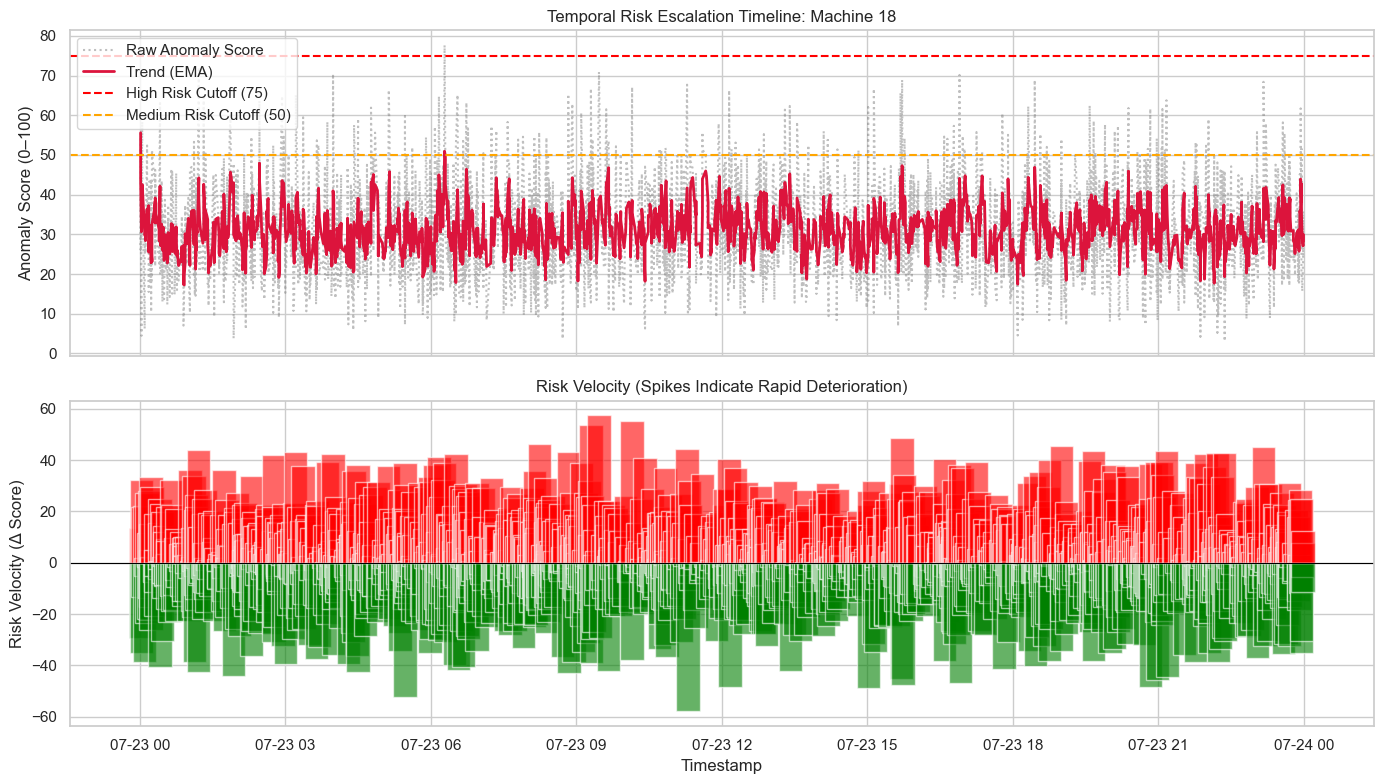

In [36]:
# EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    # Load processed dataframe
    data = pd.read_csv("processed_predictive_maintenance_results.csv")

    # 1. Calculate Temporal Escalation Metrics
    temporal_df = calculate_temporal_risk_metrics(data)

    # 2. Generate Machine Escalation Summary
    summary_df, flagged_records = identify_escalating_machines(temporal_df)

    print("\n--- Top Priority Machines Showing Risk Escalation ---")
    print(summary_df.head(10).to_string(index=False))

    # 3. Visualize Temporal Escalation for the Top High-Risk Machine
    top_machine = summary_df.iloc[0]['Machine_ID']
    plot_temporal_risk_escalation(temporal_df, machine_id=top_machine)